# States

In [420]:
import pandas as pd

In [421]:
df=pd.read_csv('../data/cville_weather_cleaned.csv')

In [422]:
def classify_weather(row):
    if row["WT06"] == 1:
        return "Ice"
    
    if row["WT04"] == 1:
        return "Sleet"
    
    if row["WT18"] == 1:
        return "Snow"
    
    if row["WT03"] == 1:
        return "Thunder"
    
    if row["WT05"] == 1:
        return "Hail"
    
    if row["WT16"] == 1 or row["PRCP"] > 0:
        if row["PRCP"] > 13:
            return "Heavy-Rain"
        elif row["WT14"] == 1:
            return "Drizzle"
        elif row["TMAX"] > 83:
            return "Hot-Rainy"
        elif row["TMIN"] < 54:
            return "Cold-Rainy"
        else:
            return "Mild-Rainy"
    
    if row["WT11"] == 1:
        return "High Winds"
    
    if row["WT01"] == 1:
        return "Fog"
    
    if row["TMAX"] > 83:
        return "Hot-Dry"
    elif row["TMIN"] < 54:
        return "Cold-Dry"
    else:
        return "Mild-Dry"

In [423]:
df = df.sort_values("DATE").reset_index(drop=True)
df["state"] = df.apply(classify_weather, axis=1)

In [415]:
df["DATE"] = pd.to_datetime(df["DATE"])

train_df = df[df["DATE"].dt.year <= 2024].copy()
test_df  = df[df["DATE"].dt.year == 2025].copy()

In [424]:
df["next_state"] = df["state"].shift(-1)
df["next_2_states"] = df["state"].shift(-2)
df["next_week"] = df["state"].shift(-7)
df["next_2_weeks"] = df["state"].shift(-14)

df = df.dropna(subset=["next_state", "next_2_states", "next_week", "next_2_weeks"])

In [425]:
train_df["next_state"] = train_df["state"].shift(-1)
train_df = train_df.dropna(subset=["next_state"])

In [427]:
df.to_csv("../data/cville_weather_cleaned.csv", index=False)

# Transition Probability Matrix Full Dataset

In [428]:
import seaborn as sns
import matplotlib.pyplot as plt

full_matrix = pd.crosstab(
    train_df["state"], 
    train_df["next_state"], 
    normalize="index"
)

states = sorted(train_df["state"].unique())

full_matrix = full_matrix.reindex(
    index=states,
    columns=states,
    fill_value=0
)

row_sums = full_matrix.sum(axis=1)
for state in states:
    if row_sums[state] == 0:
        full_matrix.loc[state, state] = 1.0

plt.figure(figsize=(12, 8))

sns.heatmap(
    full_matrix,
    annot=True,
    cmap="Blues",
    cbar=True
)

plt.title("Transition Matrix (Full Dataset)")
plt.xlabel("Next State")
plt.ylabel("Current State")

plt.tight_layout()

plt.savefig(
    "../outputs/transition_matrices/Full_transition_matrix.png",
    dpi=75,
    bbox_inches="tight"
)
plt.close()

# Transition Matrices Seasonal

In [429]:
states = sorted(df["state"].unique())
season_matrices = {}

for season in train_df["season"].unique():
    season_df = train_df[train_df["season"] == season]
    
    seasonal_matrix = pd.crosstab(
        season_df["state"],
        season_df["next_state"],
        normalize="index"
    )
    
    seasonal_matrix = seasonal_matrix.reindex(index=states, columns=states, fill_value=0)
    
    row_sums = seasonal_matrix.sum(axis=1)
    for state in states:
        if row_sums[state] == 0:
            seasonal_matrix.loc[state, state] = 1.0
            
    season_matrices[season] = seasonal_matrix

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        seasonal_matrix, 
        cmap="Blues", 
        annot=True, 
        fmt=".2f", 
        square=True,
        cbar_kws={'label': 'Transition Probability'}
    )

    plt.title(f"Transition Matrix: {season} (Training Data)", fontsize=14)
    plt.xlabel("Next State (Predicted)")
    plt.ylabel("Current State (Actual)")
    plt.tight_layout()
    plt.savefig(f"../outputs/transition_matrices/{season} Transition Matrix")
    plt.close() 

# DTMC Model

In [430]:
import numpy as np
from pydtmc import MarkovChain
print("pydtmc installed correctly")

pydtmc installed correctly


In [431]:
def predict_next(current_state, P_matrix):
    i = states.index(current_state)
    return np.random.choice(states, p=P_matrix[i])

## Full Dataset

In [432]:
P_full = full_matrix.values
forecast_full = []

for i in range(len(test_df)):
    if i == 0:
        current_input = train_df.iloc[-1]["state"]
    else:
        current_input = test_df.iloc[i-1]["state"]  

    forecast_full.append(predict_next(current_input, P_full))

test_df["pred_state"] = forecast_full

## Seasonal 

In [433]:
forecast_seasonal = []

for i in range(len(test_df)):
    season = test_df.iloc[i]["season"]

    if i == 0:
        current_input = train_df.iloc[-1]["state"]
    else:
        current_input = forecast_seasonal[i-1]

    P_season = season_matrices[season].values

    forecast_seasonal.append(predict_next(current_input, P_season))

test_df["pred_state_seasonal"] = forecast_seasonal

# Comparison Across Multiple Time Frames 

In [434]:
horizons = [1, 2, 7, 14]
states = sorted(train_df["state"].unique())
state_to_idx = {s: i for i, s in enumerate(states)}
P_full_mat = full_matrix.values  

full_metrics = {"Horizon": [], "Log-Likelihood": [], "Top-3 Accuracy": []}

for n in horizons:
    P_n = np.linalg.matrix_power(P_full_mat, n)
    
    log_liks = []
    top_3_correct = 0
    total_samples = 0
    
    for i in range(len(test_df) - n):
        curr_state = test_df.iloc[i]["state"]
        true_future = test_df.iloc[i + n]["state"]
        
        curr_idx = state_to_idx[curr_state]
        futu_idx = state_to_idx[true_future]
        
        prob = P_n[curr_idx, futu_idx]
        log_liks.append(np.log(prob + 1e-12))
        
        if futu_idx in np.argsort(P_n[curr_idx])[-3:]:
            top_3_correct += 1
        total_samples += 1
    
    full_metrics["Horizon"].append(n)
    full_metrics["Log-Likelihood"].append(np.mean(log_liks))
    full_metrics["Top-3 Accuracy"].append(top_3_correct / total_samples)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Horizon (Days)')
ax1.set_ylabel('Top-3 Accuracy', color='tab:blue')
ax1.plot(full_metrics["Horizon"], full_metrics["Top-3 Accuracy"], marker='o', color='tab:blue', label='Accuracy')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Log-Likelihood', color='tab:red')
ax2.plot(full_metrics["Horizon"], full_metrics["Log-Likelihood"], marker='s', color='tab:red', linestyle='--', label='Log-Likelihood')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Full Model Performance Trend (1, 2, 7, 14 Days)')
plt.xticks(horizons)
plt.grid(True, alpha=0.3)
plt.savefig("../outputs/full_model_performance_trend.png")
plt.close()

In [435]:
seasonal_metrics = {"Horizon": [], "Log-Likelihood": [], "Top-3 Accuracy": []}

for n in horizons:
    log_liks = []
    top_3_correct = 0
    total_samples = 0
    
    for i in range(len(test_df) - n):
        season = test_df.iloc[i]["season"]
        curr_state = test_df.iloc[i]["state"]
        true_future = test_df.iloc[i + n]["state"]
        
        curr_idx = state_to_idx[curr_state]
        futu_idx = state_to_idx[true_future]
        
        P_season = season_matrices[season].values
        P_n = np.linalg.matrix_power(P_season, n)
        
        prob = P_n[curr_idx, futu_idx]
        log_liks.append(np.log(prob + 1e-12))
        
        if futu_idx in np.argsort(P_n[curr_idx])[-3:]:
            top_3_correct += 1
        total_samples += 1
        
    seasonal_metrics["Horizon"].append(n)
    seasonal_metrics["Log-Likelihood"].append(np.mean(log_liks))
    seasonal_metrics["Top-3 Accuracy"].append(top_3_correct / total_samples)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Horizon (Days)')
ax1.set_ylabel('Top-3 Accuracy', color='tab:green')
ax1.plot(seasonal_metrics["Horizon"], seasonal_metrics["Top-3 Accuracy"], marker='o', color='tab:green', label='Accuracy')
ax1.tick_params(axis='y', labelcolor='tab:green')

ax2 = ax1.twinx()
ax2.set_ylabel('Log-Likelihood', color='tab:purple')
ax2.plot(seasonal_metrics["Horizon"], seasonal_metrics["Log-Likelihood"], marker='s', color='tab:purple', linestyle='--', label='Log-Likelihood')
ax2.tick_params(axis='y', labelcolor='tab:purple')

plt.title('Seasonal Model Performance Trend (1, 2, 7, 14 Days)')
plt.xticks(horizons)
plt.grid(True, alpha=0.3)
plt.savefig("../outputs/seasonal_model_performance_trend.png")
plt.close()

# Second Order Chain

In [436]:
train_df = train_df.sort_values("DATE").reset_index(drop=True)

train_df["prev_state"] = train_df["state"].shift(1)
train_df["state_2nd"] = train_df["prev_state"] + "|" + train_df["state"]
train_df["next_state_2nd"] = train_df["state"].shift(-1)

train_df = train_df.dropna(subset=["prev_state", "next_state_2nd"])

In [437]:
states_2nd = sorted(train_df["state_2nd"].unique())
state_to_idx = {s: i for i, s in enumerate(states_2nd)}

matrix_2nd = pd.crosstab(
    train_df["state_2nd"],
    train_df["next_state_2nd"],
    normalize="index"
)

In [438]:
prev = train_df.iloc[-1]["prev_state"]  
curr = train_df.iloc[-1]["state"]       

forecast_2nd = []
states_1st = sorted(train_df["state"].unique())  

for i in range(len(test_df)):
    compound = f"{prev}|{curr}"
    
    if compound in matrix_2nd.index:
        probs = matrix_2nd.loc[compound].reindex(states_1st, fill_value=0).values
    else:
        probs = np.ones(len(states_1st)) / len(states_1st)
    
    probs = probs / probs.sum()
    next_state = np.random.choice(states_1st, p=probs)
    forecast_2nd.append(next_state)
    
    prev = curr
    curr = test_df.iloc[i]["state"]  

test_df["pred_state_2nd"] = forecast_2nd

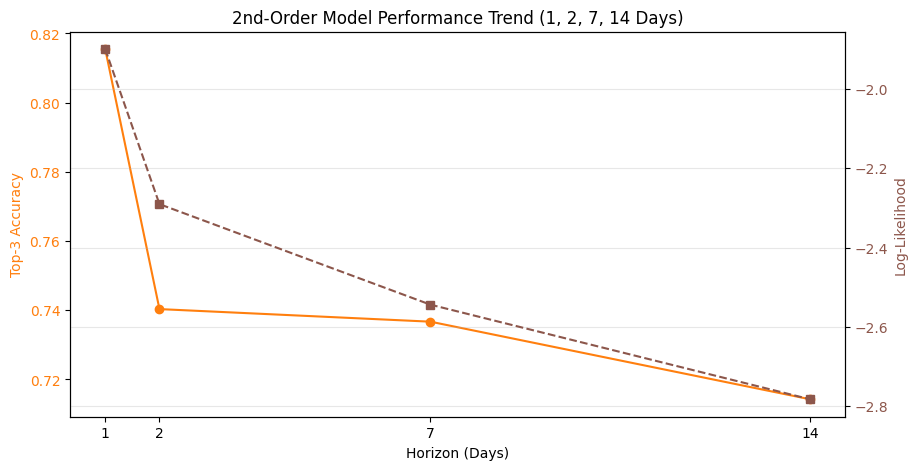

In [440]:
metrics_2nd = {"Horizon": [], "Log-Likelihood": [], "Top-3 Accuracy": []}

P_2nd = matrix_2nd.reindex(columns=states_1st, fill_value=0).values

for n in horizons:
    log_liks = []
    top_3_correct = 0
    total = 0

    for i in range(len(test_df) - n):
        prev = train_df.iloc[-1]["state"] if i == 0 else test_df.iloc[i-1]["state"]
        curr = test_df.iloc[i]["state"]
        compound = f"{prev}|{curr}"
        true_future = test_df.iloc[i + n]["state"]

        if compound not in matrix_2nd.index:
            continue

        row_idx = list(matrix_2nd.index).index(compound)
        fut_idx = states_1st.index(true_future)

        prob = P_2nd[row_idx, fut_idx]
        log_liks.append(np.log(prob + 1e-12))

        if fut_idx in np.argsort(P_2nd[row_idx])[-3:]:
            top_3_correct += 1
        total += 1

    metrics_2nd["Horizon"].append(n)
    metrics_2nd["Log-Likelihood"].append(np.mean(log_liks))
    metrics_2nd["Top-3 Accuracy"].append(top_3_correct / total)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Horizon (Days)')
ax1.set_ylabel('Top-3 Accuracy', color='tab:orange')
ax1.plot(metrics_2nd["Horizon"], metrics_2nd["Top-3 Accuracy"], marker='o', color='tab:orange', label='Accuracy')
ax1.tick_params(axis='y', labelcolor='tab:orange')

ax2 = ax1.twinx()
ax2.set_ylabel('Log-Likelihood', color='tab:brown')
ax2.plot(metrics_2nd["Horizon"], metrics_2nd["Log-Likelihood"], marker='s', color='tab:brown', linestyle='--', label='Log-Likelihood')
ax2.tick_params(axis='y', labelcolor='tab:brown')

plt.title('2nd-Order Model Performance Trend (1, 2, 7, 14 Days)')
plt.xticks(horizons)
plt.grid(True, alpha=0.3)
plt.show()